,Reasoning Type,Count,Base Model Accuracy,2-Stage QwenVL Accuracy
0,Find Extremum,68,88.24%,88.24%
1,Filter,52,88.46%,78.85%
2,Compare,51,88.24%,80.39%
3,KCS,29,79.31%,82.76%
4,Compute Derived Value,24,91.67%,83.33%
5,Retrieve Value,21,90.48%,85.71%
6,Chart Features,18,94.44%,100.0%
7,Multichart,10,70.0%,80.0%
8,Determine Range,5,100.0%,100.0%
9,Multiaxis,1,100.0%,100.0%


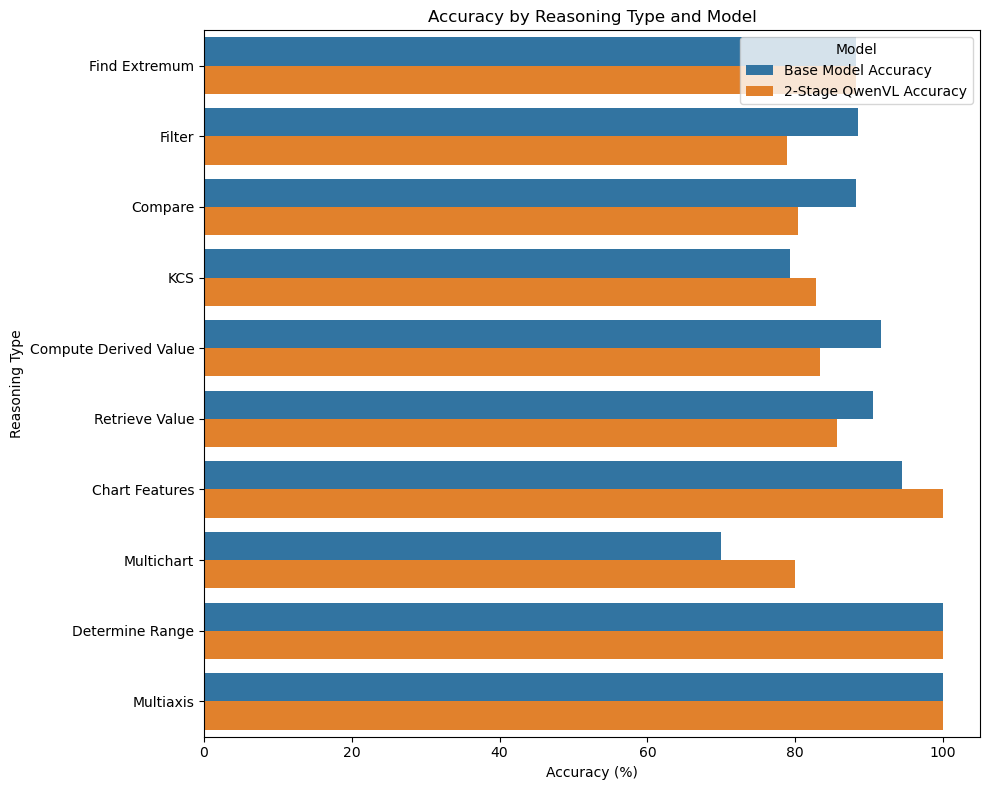


Note: When claims had multiple reasoning types, each type is counted separately.
Total unique samples with reasoning types: 173


In [6]:
import pandas as pd
import re
import seaborn as sns

# 1. Load the CSV files
df_base = pd.read_csv('results/basemodel_full_results.csv')
df_2stage = pd.read_csv('results/2-stage-qwenvl_results.csv')

# 2. Select relevant columns and rename for clarity before merging
df_base = df_base[['Claim', 'Reasoning Type', 'Verdict Match']].rename(columns={'Verdict Match': 'Base_Match'})
df_2stage = df_2stage[['Claim', 'Verdict Match']].rename(columns={'Verdict Match': '2Stage_Match'})

# 3. Merge the dataframes on 'Claim' to align the predictions
df_merged = pd.merge(df_base, df_2stage, on='Claim', how='inner')

# 4. Convert 'Match' columns to actual booleans
df_merged['Base_Match'] = df_merged['Base_Match'].astype(str).str.lower() == 'true'
df_merged['2Stage_Match'] = df_merged['2Stage_Match'].astype(str).str.lower() == 'true'

# 5. Define a function to clean the Reasoning Types
def clean_reasoning_type(text):
    if pd.isna(text):
        return str(text)
    
    text = str(text)
    text = re.sub(r'\s*\(.*?\)', '', text)
    
    return text

# Apply the cleaning function
df_merged['Cleaned_Reasoning'] = df_merged['Reasoning Type'].apply(clean_reasoning_type)

# 6. Expand rows with multiple reasoning types (comma-separated)
df_expanded = df_merged.explode('Cleaned_Reasoning', ignore_index=False)
df_expanded = df_expanded.reset_index(drop=True)  # Add this line
df_expanded['Cleaned_Reasoning'] = df_expanded['Cleaned_Reasoning'].str.split(',').apply(lambda x: [s.strip() for s in x])
df_expanded = df_expanded.explode('Cleaned_Reasoning', ignore_index=True)

# 7. Filter out the "unknown" reasoning types
df_filtered = df_expanded[df_expanded['Cleaned_Reasoning'].str.lower() != 'unknown']

# 8. Group by the cleaned reasoning type to calculate Count and Accuracies
summary_table = df_filtered.groupby('Cleaned_Reasoning').agg(
    Count=('Claim', 'count'),
    Base_Accuracy=('Base_Match', 'mean'),
    TwoStage_Accuracy=('2Stage_Match', 'mean')
).reset_index()

# 9. Format the accuracies as percentages
summary_table['Base_Accuracy'] = (summary_table['Base_Accuracy'] * 100).round(2).astype(str) + '%'
summary_table['TwoStage_Accuracy'] = (summary_table['TwoStage_Accuracy'] * 100).round(2).astype(str) + '%'

# Rename columns
summary_table = summary_table.rename(columns={
    'Cleaned_Reasoning': 'Reasoning Type',
    'Base_Accuracy': 'Base Model Accuracy',
    'TwoStage_Accuracy': '2-Stage QwenVL Accuracy'
})

# Sort by count
summary_table = summary_table.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Add total row
total_count = summary_table['Count'].sum()
total_row = pd.DataFrame([{
    'Reasoning Type': 'Total',
    'Count': total_count,
    'Base Model Accuracy': '-',
    '2-Stage QwenVL Accuracy': '-'
}])
summary_table = pd.concat([summary_table, total_row], ignore_index=True)

# 10. Display the table
display(summary_table)
import matplotlib.pyplot as plt

# Prepare data for plotting
df_plot = summary_table[summary_table['Reasoning Type'] != 'Total'].copy()
df_plot = df_plot.sort_values('Count', ascending=False)
df_plot['Base Model Accuracy'] = df_plot['Base Model Accuracy'].str.rstrip('%').astype(float)
df_plot['2-Stage QwenVL Accuracy'] = df_plot['2-Stage QwenVL Accuracy'].str.rstrip('%').astype(float)

# Melt the dataframe for plotting
df_melted = df_plot.melt(id_vars=['Reasoning Type', 'Count'], value_vars=['Base Model Accuracy', '2-Stage QwenVL Accuracy'], var_name='Model', value_name='Accuracy')

# Plot horizontal bar chart
plt.figure(figsize=(10, 8))
order = df_plot['Reasoning Type'].tolist()
sns.barplot(data=df_melted, y='Reasoning Type', x='Accuracy', hue='Model', order=order, orient='h')
plt.title('Accuracy by Reasoning Type and Model')
plt.xlabel('Accuracy (%)')
plt.ylabel('Reasoning Type')
plt.legend(title='Model')
plt.tight_layout()
plt.show()
# Explanation
print("\nNote: When claims had multiple reasoning types, each type is counted separately.")
print(f"Total unique samples with reasoning types: {df_filtered['Claim'].nunique()}")